# Task 4 — measured contrastive graph–text retrieval

Review the completed three-seed experiment on 3,964 real MusicCaps pairs.
Trained DistilBERT and temporal GraphSAGE are frozen. Two small linear heads
project their cached representations into a normalized 64-dimensional space.
Symmetric InfoNCE uses matching IDs as positives and other batch pairs as negatives.

Default execution reads saved results and demonstrates validation retrieval;
it does not retrain or repeat final test inference. See `report/task4_results.md`
and `docs/task4/README.md` for full methods, limitations and reproduction.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RUN = ROOT / 'results/task4/available_run1'
assert (RUN / 'test_evaluation.json').exists(), 'Run the Task 4 suite first; see docs/task4/README.md.'
selection = json.loads((RUN / 'selection.json').read_text(encoding='utf-8'))
declaration = json.loads((RUN / 'suite_config.json').read_text(encoding='utf-8'))
verification = json.loads((RUN / 'verification.json').read_text(encoding='utf-8'))
assert not declaration['synthetic'] and verification['valid']
print('Real paired data | Seeds:', selection['seeds'])
print('Selection:', declaration['selection_metric'])
display(pd.DataFrame([verification]))

Real paired data | Seeds: [42, 43, 44]
Selection: Mean bidirectional validation Recall@1; earliest epoch breaks ties


,valid,seeds,feature_sha256,evaluated_test,validation_only_selection,unit_embeddings_verified,metrics_recomputed,baseline_metrics_recomputed,split_ids_verified,checkpoint_hashes_verified,comparison_tables_verified
0,True,"[42, 43, 44]",77c667b7312a6579ef17f0a29da5170781829a1a784915...,True,True,True,True,True,True,True,True


## Bidirectional held-out comparison

Every seed uses the same 606 test queries and gallery. Recall is a fraction in
the CSV below. Mean and sample standard deviation summarize projection seeds,
not encoder variation or statistical confidence. Initial projections are the
exact pretraining weights for each seed. Random expected Recall@K is K/606.
CLAP is reported in the extension section; human listening remains pending.

,split,baseline,direction,recall_at_1_mean,recall_at_1_std,recall_at_5_mean,recall_at_5_std,recall_at_10_mean,recall_at_10_std,median_rank_mean,median_rank_std,mean_reciprocal_rank_mean,mean_reciprocal_rank_std
4,test,trained,text_to_graph,0.025853,0.000953,0.106161,0.004153,0.177668,0.009088,52.166667,4.252450,0.079990,0.001487
5,test,trained,graph_to_text,0.028053,0.004366,0.111111,0.004153,0.186469,0.001650,50.666667,1.443376,0.082926,0.001536
6,test,untrained,text_to_graph,0.001100,0.001905,0.004400,0.001905,0.008251,0.001650,314.833333,4.932883,0.009134,0.001750
7,test,untrained,graph_to_text,0.001650,0.001650,0.008251,0.003300,0.017052,0.010987,321.833333,12.789970,0.011152,0.003131


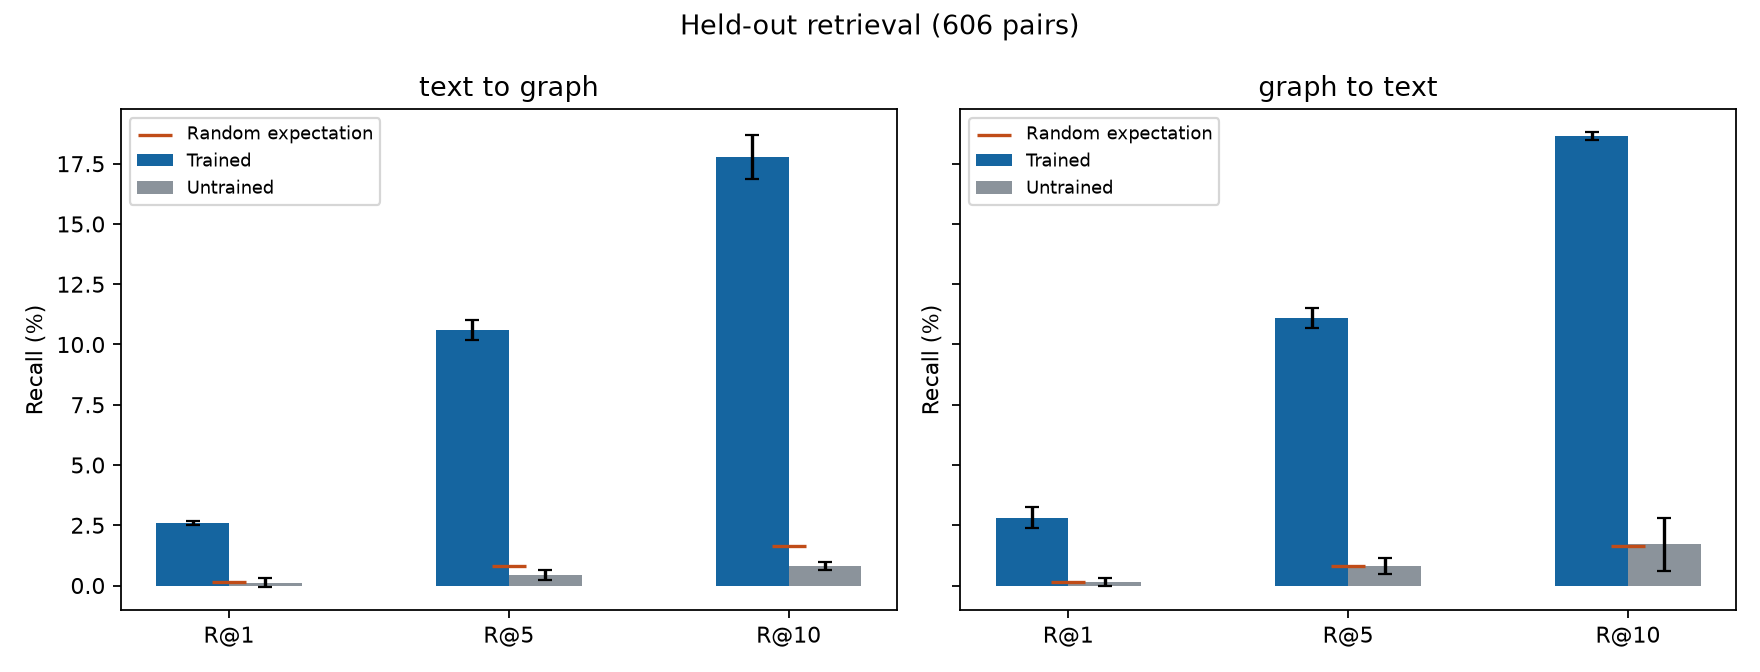

,seed,split,baseline,direction,gallery_size,recall_at_1,recall_at_5,recall_at_10,median_rank,mean_reciprocal_rank
0,42,validation,trained,text_to_graph,583,0.042882,0.118353,0.219554,45.0,0.100185
1,42,validation,trained,graph_to_text,583,0.029160,0.132075,0.228130,44.0,0.093690
4,42,test,trained,text_to_graph,606,0.026403,0.110561,0.178218,52.0,0.080923
5,42,test,trained,graph_to_text,606,0.029703,0.107261,0.188119,51.5,0.083691
8,43,validation,trained,text_to_graph,583,0.032590,0.128645,0.205832,47.0,0.094799
9,43,validation,trained,graph_to_text,583,0.037736,0.135506,0.217839,46.0,0.099826
12,43,test,trained,text_to_graph,606,0.024752,0.102310,0.186469,48.0,0.080773
13,43,test,trained,graph_to_text,606,0.023102,0.115512,0.184818,49.0,0.081158
16,44,validation,trained,text_to_graph,583,0.041166,0.111492,0.204117,44.0,0.097576
17,44,validation,trained,graph_to_text,583,0.036021,0.118353,0.188679,47.0,0.090042


In [2]:
comparison = pd.read_csv(RUN / 'comparison.csv')
aggregate = pd.read_csv(RUN / 'comparison_aggregate.csv')
display(aggregate[aggregate.split == 'test'])
display(Image(filename=str(RUN / 'analysis/retrieval_comparison.png')))
display(comparison[comparison.baseline == 'trained'])

## Training and validation-only selection

Batch size 32, temperature 0.07, AdamW learning rate 0.001, weight decay 0.01,
at most 30 epochs, patience 5. Earliest maximum validation mean Recall@1 selects
each checkpoint. All seeds and checkpoint hashes were frozen before test inference.
Stars mark selected epochs; final training-loss minima do not select checkpoints.

,seed,checkpoint,best_epoch,validation_mean_recall_at_1
0,42,seed42/best_model.pt,6,0.036021
1,43,seed43/best_model.pt,9,0.035163
2,44,seed44/best_model.pt,12,0.038593


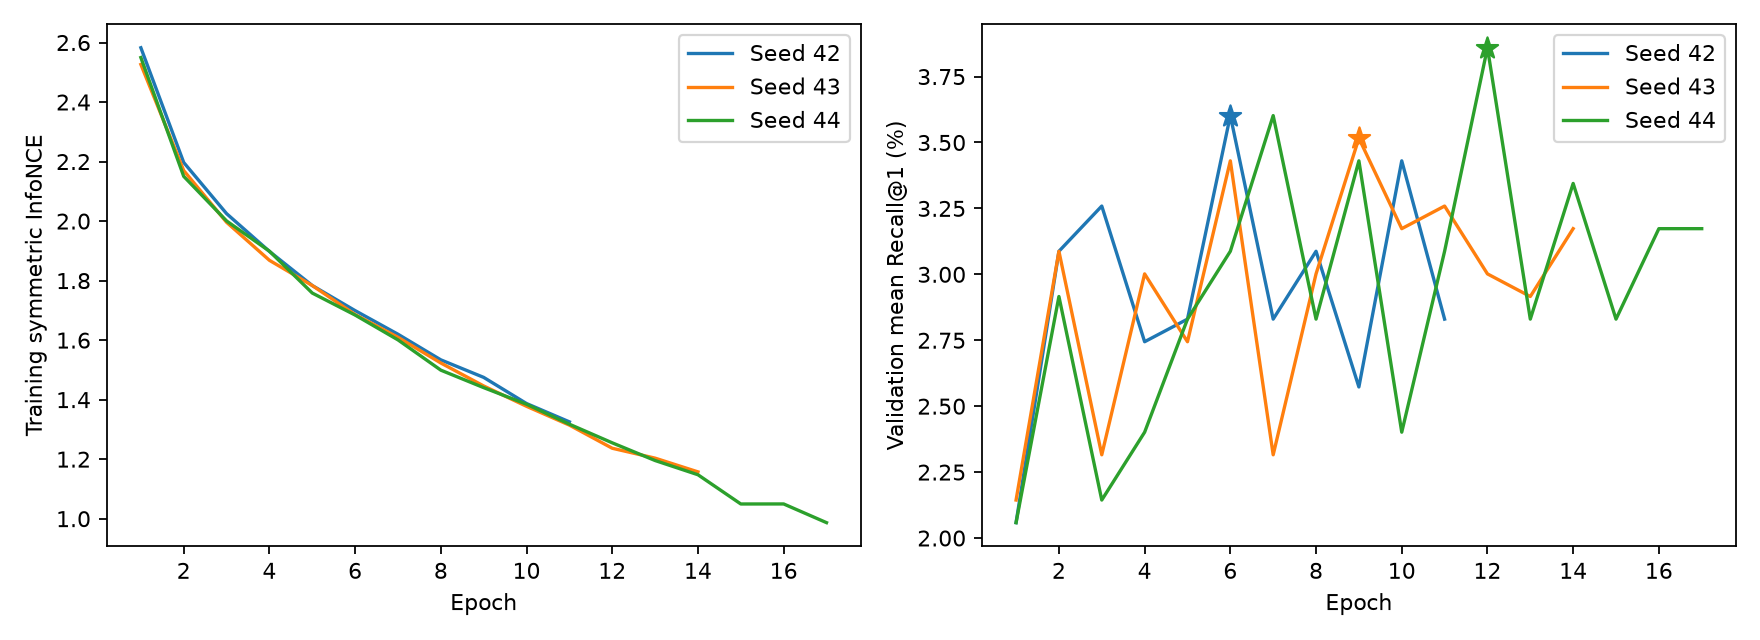

**Seed 42: loss and directional validation recall**

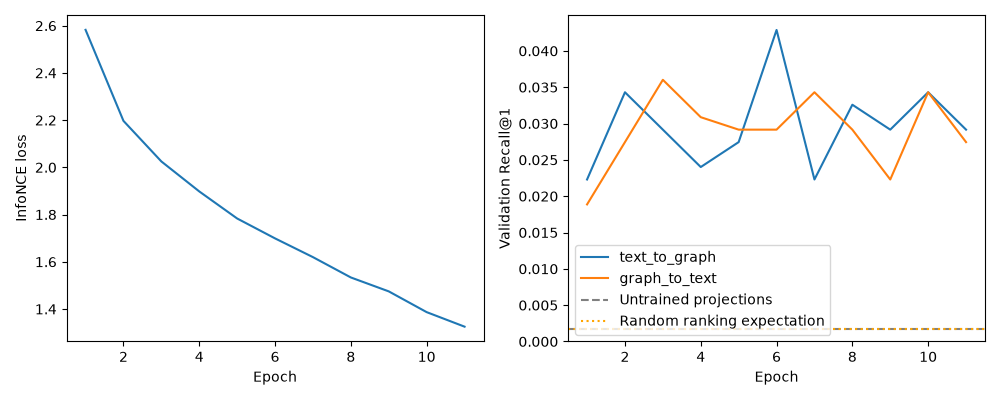

**Seed 43: loss and directional validation recall**

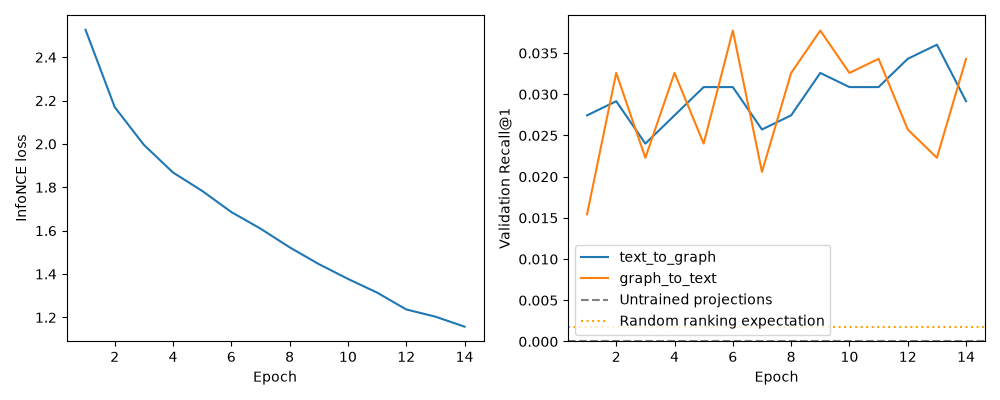

**Seed 44: loss and directional validation recall**

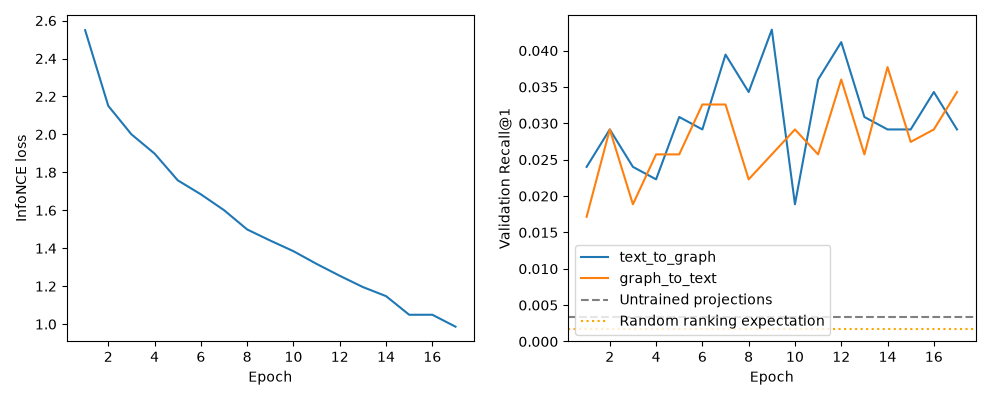

In [3]:
display(pd.DataFrame([{k: v for k, v in r.items() if k not in {'artifacts', 'feature_sha256'}} for r in selection['runs']]))
display(Image(filename=str(RUN / 'analysis/learning_curves.png')))
for seed in selection['seeds']:
    display(Markdown(f'**Seed {seed}: loss and directional validation recall**'))
    display(Image(filename=str(RUN / f'seed{seed}/learning_curves.png')))

## Independent metric recomputation

Recompute both trained and initial-baseline metrics directly from saved test
embeddings. No checkpoint inference occurs. File hashes connect these artifacts
to the frozen suite; IDs preserve row pairing.

In [4]:
from src.task3.data import feature_fingerprint
from src.task4.metrics import recompute
final = json.loads((RUN / 'test_evaluation.json').read_text(encoding='utf-8'))
assert feature_fingerprint(RUN / 'selection.json') == final['selection_sha256']
for seed in selection['seeds']:
    directory = RUN / f'seed{seed}/test'
    report = json.loads((directory / 'metrics.json').read_text(encoding='utf-8'))
    for filename, key in [('embeddings.npz', 'metrics'), ('untrained_embeddings.npz', 'untrained_projection_metrics')]:
        path = directory / filename
        assert feature_fingerprint(path) == final['artifacts'][path.relative_to(RUN).as_posix()]
        assert recompute(path) == report[key]
print('All six held-out embedding archives reproduce their bidirectional metrics.')

All six held-out embedding archives reproduce their bidirectional metrics.


## Retrieval demonstration from saved embeddings

Use the first declared seed and first validation query by default. Change
`DIRECTION` or `QUERY_INDEX` to inspect another cached query. Candidate captions
describe the associated tracks; no new raw text/audio is encoded in this cell.
Tied negatives rank ahead of the positive, matching aggregate metrics.

In [5]:
from src.task4.metrics import normalized_pairs, paired_ranks
DIRECTION = 'text_to_graph'  # or 'graph_to_text'
QUERY_INDEX = 0
seed = selection['seeds'][0]
with np.load(RUN / f'seed{seed}/validation/embeddings.npz', allow_pickle=False) as saved:
    texts, graphs = normalized_pairs(saved['text'], saved['graph'])
    ids = saved['sample_ids'].tolist()
queries, gallery = (texts, graphs) if DIRECTION == 'text_to_graph' else (graphs, texts)
assert 0 <= QUERY_INDEX < len(ids)
scores = queries[QUERY_INDEX] @ gallery.T
order = np.lexsort((np.arange(len(ids)) == QUERY_INDEX, -scores))[:10]
print('Direction:', DIRECTION, '| Query:', ids[QUERY_INDEX])
print('Paired rank:', int(paired_ranks(queries, gallery)[QUERY_INDEX]), '/', len(ids))
display(pd.DataFrame([{'rank': rank, 'sample_id': ids[i], 'cosine': float(scores[i]),
                       'paired_positive': bool(i == QUERY_INDEX)} for rank, i in enumerate(order, 1)]))

Direction: text_to_graph | Query: -5xOcMJpTUk_70_80
Paired rank: 2 / 583


,rank,sample_id,cosine,paired_positive
0,1,7NF2kcEfMBI_420_430,0.745389,False
1,2,-5xOcMJpTUk_70_80,0.701979,True
2,3,9ZWmZdgrE78_80_90,0.683888,False
3,4,IAeYandwJqc_70_80,0.673362,False
4,5,89eBh_Djflw_240_250,0.667088,False
5,6,CKEPPcaCjbw_60_70,0.642875,False
6,7,hRQJgZVxRX0_30_40,0.622984,False
7,8,iSw-5EjXgXc_30_40,0.616582,False
8,9,-_OzT7Xyvok_30_40,0.614194,False
9,10,YgX85tZf1ts_300_310,0.605676,False


## Examples, failures and duplicate captions

Fixed first-three queries and explicitly marked best/worst-rank diagnostics use
the first declared seed. These are caption-based observations, not listening
judgments. Distinct descriptions of similar music can be false negatives even
when exact/normalized duplicates are absent.

In [6]:
audit = json.loads((RUN / 'pairing_audit.json').read_text(encoding='utf-8'))
display(pd.DataFrame([{'samples': audit['samples'], **audit['split_counts'],
                       'exact_duplicate_groups': len(audit['exact_caption_duplicates']),
                       'normalized_duplicate_groups': len(audit['normalized_caption_duplicates']),
                       'repeated_video_groups': len(audit['repeated_videos'])}]))
display(Markdown((RUN / 'analysis/cases.md').read_text(encoding='utf-8')))

,samples,train,validation,test,exact_duplicate_groups,normalized_duplicate_groups,repeated_video_groups
0,3964,2775,583,606,0,0,0


# Retrieval diagnostics: seed 42, test

Three fixed queries per direction plus best/worst-rank diagnostics. Outcome-selected examples illustrate extremes, not typical quality. Captions below are dataset annotations; no human listening evaluation was performed.

## text_to_graph: -4NLarMj4xU_30_40

Selection: `fixed_first_three`. Paired rank: **200 / 606**.

Query/paired caption: The Pop song features a soft female vocal singing over sustained pulsating synth lead, mellow piano melody, sustained synth brass, punchy kick, claps. tinny wide hi hats and high pitched female vocal melody. It sounds emotional, sad, passionate and like something you would hear on a radio.

- Rank 1: `Ysrlv2UlG8A_30_40`; cosine 0.6197; nonmatching ID. The song is instrumental. The tempo is medium with electrical current manipulation to produce different frequencies to play percussively and harmonically with each other. The song is for scientific research and not pleasing to the ear. The song is of poor audio quality.
- Rank 2: `Ycid0vBwqUg_160_170`; cosine 0.5808; nonmatching ID. This is a mellow and soulful 2000s R&B song. The female vocalist gives a sensual and passionate vocal performance. The song is seductive, intimate and relaxed. There are string-like sounds and a warm and bright pad-synth along with the mellow groovy drum beat.
- Rank 3: `ICtri0ElFZc_30_40`; cosine 0.5786; nonmatching ID. This is a traditional middle eastern type of song with traditional singing that involves vocal modulation. The percussion is simple and encourages dancing. The three men sing in unison and there's an intermittent chant. They repeat the same phrase like a refrain.

## text_to_graph: -6pcgdLfb_A_110_120

Selection: `fixed_first_three`. Paired rank: **48 / 606**.

Query/paired caption: This is an R&B/soul music piece. There is a male vocalist singing melodically and in a sensual manner over multiple tracks. The melody of the beat is provided by a string sample. There is a strong bass sound in the piece. The rhythm is provided by a groovy electronic drum beat. There is an urban feel to this piece. It could be used in the soundtrack of a TV series where two characters are sharing intimate moments.

- Rank 1: `UDS6PrY9ZIM_130_140`; cosine 0.5848; nonmatching ID. This pop song features a female voice singing the main melody. At the highest pitch, her voice goes into falsetto. This is accompanied by percussion playing a simple beat in common time. An electric guitar plays a repetitive two note phrase in the background. Another guitar player fills in the background. The bass plays the root notes of the chords. This song can be played in a romantic movie.
- Rank 2: `4QES-SJ7mP0_210_220`; cosine 0.5839; nonmatching ID. A four chord modern hip hop/ R&B production featuring synthesizer pads, electronic drums, a female vocalist in a minor key.
- Rank 3: `ICtri0ElFZc_30_40`; cosine 0.5626; nonmatching ID. This is a traditional middle eastern type of song with traditional singing that involves vocal modulation. The percussion is simple and encourages dancing. The three men sing in unison and there's an intermittent chant. They repeat the same phrase like a refrain.

## text_to_graph: -7wUQP6G5EQ_30_40

Selection: `fixed_first_three`. Paired rank: **322 / 606**.

Query/paired caption: The low quality recording features a renaissance music that consists of soft wooden percussion and mellow, harmonized flute melody playing on top of it. The recording is a bit noisy, but it also sounds soulful, mellow, passionate, emotional and vintage - It really puts the listener in a period of renaissance.

- Rank 1: `I6eU2qRjJ7Y_520_530`; cosine 0.5718; nonmatching ID. This music is instrumental. The tempo is medium with a dramatic, intense and suspenseful synthesiser arrangement, cymbal riff and conch shell sound. The music is a background score for a Bengali movie / TV series with a male voice giving instructions, a Hindu priest chanting Om with women joining in with the chant and vocalisations and the sound of the conch shell.
- Rank 2: `B9ME0Vcm_xA_190_200`; cosine 0.5465; nonmatching ID. This is an instrumental alternative music piece. There are two electric guitars with heavy effects playing chill melodies. A distinct crackling effect can be heard. The rhythm consists of a medium tempo percussion beat. The atmosphere is trippy. This piece can be used in the soundtrack of a drama movie, especially during a flashback scene involving good memories.
- Rank 3: `NUTaOnEhvzE_40_50`; cosine 0.5329; nonmatching ID. The song is an instrumental. The song is slow tempo with three accordions playing in harmony and in a relaxed manner. The song is beautiful and romantic. The audio quality is average and an amateur home recording.

## text_to_graph: 4VbXYuCz4M0_30_40

Selection: `best_rank_diagnostic`. Paired rank: **1 / 606**.

Query/paired caption: The low quality recording features a live performance that consists of harmonica solo melody played over acoustic rhythm guitar chords. The recording is noisy, in mono and it sounds happy and joyful.

- Rank 1: `4VbXYuCz4M0_30_40`; cosine 0.6185; paired positive. The low quality recording features a live performance that consists of harmonica solo melody played over acoustic rhythm guitar chords. The recording is noisy, in mono and it sounds happy and joyful.
- Rank 2: `Ehks1uuwR3s_30_40`; cosine 0.5817; nonmatching ID. Here we have a live recording of an artist playing on the bagpipes. He plays a piece that feels emotional and uplifting. This piece would be fitting on the battlefield to bring about conviction and courage. It is a Scottish instrument.
- Rank 3: `WcC9sKxJ1gI_10_20`; cosine 0.5701; nonmatching ID. This is a clip featuring a motif from an instrument that sounds a little like a theremin whistle. There is a fuzzy quality to the instrument as well. This song feels like an eighties pop style song.

## text_to_graph: GiTmjE7az74_30_40

Selection: `worst_rank_diagnostic`. Paired rank: **587 / 606**.

Query/paired caption: This is a video game theme cover. The theme belongs to the Super Mario franchise. The main theme is being played on an analog sounding small keyboard. There is an added rhythmic background of beatboxing in this version. The atmosphere is playful. This piece could be used in the background of arcade gaming social media content.

- Rank 1: `AAP5pAB-4jM_0_10`; cosine 0.5563; nonmatching ID. This song contains several synth pad sounds from the low, to the mid and higher register. Then the sounds stop and a glass breaking sound comes in as it gets reversed right away. This song may be playing in an advertisement.
- Rank 2: `aCA4yiPfFIg_10_20`; cosine 0.5507; nonmatching ID. The low quality recording features a hip hop song that consists of punchy snare and kick hits, shimmering hi hats and buzzy synth lead, played by a DJ that manually made beat breaks, which resulted in stuttering filter modulated synth riser. It sounds energetic and exciting thanks to that riser.
- Rank 3: `4Mm5mBgktG0_30_40`; cosine 0.5411; nonmatching ID. The song is an instrumental. The song is medium tempo with a groovy bass line, grunge keyboard tones, synth trumpet lead and techno drumming rhythm. The song is entertaining and energetic. The song is an electronic dance song with average quality recording.

## graph_to_text: -4NLarMj4xU_30_40

Selection: `fixed_first_three`. Paired rank: **175 / 606**.

Query/paired caption: The Pop song features a soft female vocal singing over sustained pulsating synth lead, mellow piano melody, sustained synth brass, punchy kick, claps. tinny wide hi hats and high pitched female vocal melody. It sounds emotional, sad, passionate and like something you would hear on a radio.

- Rank 1: `8MKemM0h5mE_30_40`; cosine 0.6350; nonmatching ID. The Afrobeats song features a flat male vocal, supported by male ad libs in the right channel of the stereo image, rapping over punchy kicks, muffled claps, syncopated snare hits and pulsating synth pad chords. At the very end of the loop there is a short snippet of groovy synth bass, as the section changes. It sounds lower in quality mainly because of the bad sound selection, as the instruments are too thin and too digital.
- Rank 2: `AcX1B_Pr-RQ_30_40`; cosine 0.6231; nonmatching ID. The low quality recording features a reggae song sung by low flat male vocals, followed by repetitive synth lead melody, groovy bass, vocal chants, claps, punchy kick hits, shimmering hi hats and open hats. It sounds energetic, suspenseful and it is in mono. At one point the vocal cracks and it sounds out of tune for a split second.
- Rank 3: `aCA4yiPfFIg_10_20`; cosine 0.6153; nonmatching ID. The low quality recording features a hip hop song that consists of punchy snare and kick hits, shimmering hi hats and buzzy synth lead, played by a DJ that manually made beat breaks, which resulted in stuttering filter modulated synth riser. It sounds energetic and exciting thanks to that riser.

## graph_to_text: -6pcgdLfb_A_110_120

Selection: `fixed_first_three`. Paired rank: **68 / 606**.

Query/paired caption: This is an R&B/soul music piece. There is a male vocalist singing melodically and in a sensual manner over multiple tracks. The melody of the beat is provided by a string sample. There is a strong bass sound in the piece. The rhythm is provided by a groovy electronic drum beat. There is an urban feel to this piece. It could be used in the soundtrack of a TV series where two characters are sharing intimate moments.

- Rank 1: `gAQiARaliPA_150_160`; cosine 0.6217; nonmatching ID. This is an upbeat Arabic dance pop song. There's an energetic male singer with a heavily autotuned voice who sings to the beat. The beat features a four on the floor kick drum pattern and hi-hats being played in a pattern of 16th notes. There's a rapid repeated synth melody riff. The song would be heard at a dance club.
- Rank 2: `5LX2Unga1p4_30_40`; cosine 0.6165; nonmatching ID. A digital drum with a strong snare that sounds like a slap is playing along with an e-bass that is being slapped, playing a funky bassline. A e-guitar is strumming two funky chords along. A female voice is rapping with a lot of confidence in the attitude and then another female voice is singing accompanied by female backing voices. The file is of poorer audio-quality. This song may be playing in a disco.
- Rank 3: `-qcTD2o6I9s_30_40`; cosine 0.5978; nonmatching ID. The kick is playing on every beat along with a fast paced high hat and a snare sound. The digital bass is adding some spice and sounds overdriven. Pad sounds can be heard in the background while a synth lead sound is playing a simple repetitive melody. A male voice is rapping/singing. A lot of backing vocals with delay are adding energy to the mix. This song may be playing in a car.

## graph_to_text: -7wUQP6G5EQ_30_40

Selection: `fixed_first_three`. Paired rank: **402 / 606**.

Query/paired caption: The low quality recording features a renaissance music that consists of soft wooden percussion and mellow, harmonized flute melody playing on top of it. The recording is a bit noisy, but it also sounds soulful, mellow, passionate, emotional and vintage - It really puts the listener in a period of renaissance.

- Rank 1: `fRpJfrfjoZo_30_40`; cosine 0.5920; nonmatching ID. The song is an instrumental music section. The song is medium tempo with a string section playing percussively with violins and cellos in harmony, flute playing a melancholic solo, percussive hits and steady bass line. The song is full of suspense and passion. The song is a Tamil movie instrumental soundtrack.
- Rank 2: `8iPpgyEh8WM_30_40`; cosine 0.5455; nonmatching ID. This is a modern classical instrumental piece. The melody is played by an orchestra with the strings section as the lead, the piano playing an arpeggio and the bass guitar carrying the background. There is a light percussive element resembling a tambourine keeping the rhythmic background. The piece has a melodic, story-telling mood to it which would make it the perfect choice to use in a movie soundtrack, especially a romantic movie.
- Rank 3: `BI8YQ3ueD24_30_40`; cosine 0.5243; nonmatching ID. Intentionally lo-fi bedroom recording of acoustic guitar strumming, knocking and fingerstyle playing. Finger snaps can also be heard. There is a slightly muffled room reverb over everything. Has an indie folk DIY aesthetic.

## graph_to_text: 1h2sb2xeCt8_30_40

Selection: `best_rank_diagnostic`. Paired rank: **1 / 606**.

Query/paired caption: The low quality recording features a ballad that consists of a soft female vocal singing over a mellow piano melody and shimmering bells at the end of the loop. The recording is noisy and it sounds passionate, emotional and mystical, almost like a lullaby.

- Rank 1: `1h2sb2xeCt8_30_40`; cosine 0.6737; paired positive. The low quality recording features a ballad that consists of a soft female vocal singing over a mellow piano melody and shimmering bells at the end of the loop. The recording is noisy and it sounds passionate, emotional and mystical, almost like a lullaby.
- Rank 2: `AGsMCWB1tTk_30_40`; cosine 0.6725; nonmatching ID. A male vocalist sings this popular Christmas carol . The tempo is medium with soft acoustic guitar and steady drumming. The emphasis is on vocals and the highlight of this song is the cheerful and perfectly synced and harmonised vocalisation. It adds layers and textures and gives this age old song a makeover. It is light, happy, peppy, joyful, playful and cheerful.
- Rank 3: `2zo5z1I0CeM_150_160`; cosine 0.6672; nonmatching ID. This pop song is sung by a female children's choir. The voices are soprano and alto. The soprano voice sings high pitch notes in vocals. The alto voices sing the words in parts. This is accompanied by the bass playing the root notes of the chords. A piano plays arpeggiated chords. The mood of this song is sad. This song can be played in a movie scene about reminiscing the past.

## graph_to_text: 3UHHjbO0ThM_30_40

Selection: `worst_rank_diagnostic`. Paired rank: **595 / 606**.

Query/paired caption: This audio contains an acoustic drum set playing fast snare rolls and then adding in a kick on every beat along with some crash hits. A synthesizer is playing a fast lead melody in the upper register. Then the song breaks into the next part and a brass/string section is playing a melody changing note on every beat together with the kick. This song may be playing for a fast paced video-game.

- Rank 1: `0Wdh45yt7tY_50_60`; cosine 0.5203; nonmatching ID. The song is an instrumental. The song is medium tempo with an accordion accompaniment, violin solo and a flute melody. The song is beautiful and nostalgic. The audio quality is poor. The song has an old gypsy soul to it.
- Rank 2: `NUTaOnEhvzE_40_50`; cosine 0.5140; nonmatching ID. The song is an instrumental. The song is slow tempo with three accordions playing in harmony and in a relaxed manner. The song is beautiful and romantic. The audio quality is average and an amateur home recording.
- Rank 3: `9uToez74x_M_30_40`; cosine 0.4953; nonmatching ID. A male country singer sings this passionate melody with backup singers in vocal harmony. The song is medium tempo with a strong drumming rhythm, guitar accompaniment, guitar lead, percussive bass line and percussion hits. The song is passionate and romantic. The song has bad audio quality.


## Scope and interpretation

Most true pairs remain outside the top ten despite improvement over both baselines.
Fixed classification-trained encoders, coarse graph features, available-audio
selection and the lack of artist-disjoint evaluation limit interpretation.
DistilBERT previously trained on 3,864 captions, including 1,089 additional
training-only captions without available paired audio; GraphSAGE trained on
2,775 paired clips. Held-out IDs retain their original splits.

No subjective quality or completed listening assessment is claimed. The original
proposal updates encoders; this projection-only experiment is a documented scope
deviation. See `report/task4_scope_deviation.md` and the extension results.

## Zero-shot comparisons and ten-query listening package

CLAP is a fixed pretrained audio/text comparator, not a graph encoder. The
caption-tag comparison separately uses positive/negative text prompt similarity,
with no local training or threshold tuning. The five-listener study is prepared
but has no real responses yet. Follow `report/task4_listening_guide.md`.

In [7]:
clap_root = ROOT / 'results/task4/clap_zeroshot'
clap = json.loads((clap_root / 'metrics.json').read_text(encoding='utf-8'))
assert recompute(clap_root / 'embeddings.npz') == clap['metrics']
display(pd.DataFrame({k: clap['metrics'][k] for k in ['text_to_graph', 'graph_to_text']}).T.rename(index={'text_to_graph':'text_to_audio_CLAP','graph_to_text':'audio_to_text_CLAP'}))
display(pd.read_csv(ROOT / 'results/task4/zeroshot_tags/comparison.csv'))
study = ROOT / 'results/task4/listening_study'
protocol = json.loads((study / 'protocol.json').read_text(encoding='utf-8'))
print('Human evaluation:', protocol['status'], '| Required listeners:', protocol['required_listeners'])
print('Each listener rates', protocol['trials_per_listener'], 'clips across', protocol['queries'], 'queries.')
display(Markdown((study / 'ten_caption_queries.md').read_text(encoding='utf-8')))

,recall_at_1,recall_at_5,recall_at_10,median_rank,mean_reciprocal_rank
text_to_audio_CLAP,0.136964,0.326733,0.453795,13.0,0.238019
audio_to_text_CLAP,0.113861,0.315182,0.409241,16.0,0.217750


,method,seed,macro_f1,micro_f1,mean_average_precision
0,zero_shot_caption_prompt_similarity,none,0.109013,0.152971,0.102511
1,task3_supervised_gated,42,0.371973,0.634584,0.401218
2,task3_supervised_gated,43,0.369403,0.641986,0.409466
3,task3_supervised_gated,44,0.370185,0.663208,0.387695


Human evaluation: awaiting_human_ratings | Required listeners: 5
Each listener rates 60 clips across 10 queries.


# Ten caption queries → top-three clips

Fixed first ten test queries; graph seed 42 and pinned zero-shot CLAP. Selected by ID order, not success. Descriptions are dataset annotations, not human assessments.

## `-4NLarMj4xU_30_40`

The Pop song features a soft female vocal singing over sustained pulsating synth lead, mellow piano melody, sustained synth brass, punchy kick, claps. tinny wide hi hats and high pitched female vocal melody. It sounds emotional, sad, passionate and like something you would hear on a radio.

**graph: paired rank 200.**

- 1. `Ysrlv2UlG8A_30_40` — cosine 0.6197; nonpaired. The song is instrumental. The tempo is medium with electrical current manipulation to produce different frequencies to play percussively and harmonically with each other. The song is  for scientific research and not  pleasing to the ear. The song is of poor audio quality.
- 2. `Ycid0vBwqUg_160_170` — cosine 0.5808; nonpaired. This is a mellow and soulful 2000s R&B song. The female vocalist gives a sensual and passionate vocal performance. The song is seductive, intimate and relaxed. There are string-like sounds and a warm and bright pad-synth along with the mellow groovy drum beat.
- 3. `ICtri0ElFZc_30_40` — cosine 0.5786; nonpaired. This is a traditional middle eastern type of song with traditional singing that involves vocal modulation. The percussion is simple and encourages dancing. The three men sing in unison and there's an intermittent chant. They repeat the same phrase like a refrain.

**clap: paired rank 1.**

- 1. `-4NLarMj4xU_30_40` — cosine 0.6747; paired. The Pop song features a soft female vocal singing over sustained pulsating synth lead, mellow piano melody, sustained synth brass, punchy kick, claps. tinny wide hi hats and high pitched female vocal melody. It sounds emotional, sad, passionate and like something you would hear on a radio.
- 2. `GFJNgqcX7u0_30_40` — cosine 0.6733; nonpaired. This is an instrumental electric guitar jam meant to showcase an echo delay pedal. The guitar using the pedal is merely strumming the chords while there is another electric guitar in the background playing the melody. There is also a bass guitar playing a simple bass line. In the rhythmic background there is a chill rock beat played by the acoustic drums. There is a calm and chill atmosphere in this piece. It could be used as the loading screen music in a video game.
- 3. `UnFEqUWTefM_60_70` — cosine 0.6529; nonpaired. A female vocalist sings this melodic song. The tempo is medium with female vocalisation, female choral backup, groovy bass lines,slick drumming, church organ harmony, and a lively piano  accompaniment that comes in at the end of this clip. The song is pleasant, melodic, insistent, repetitive and recurring  like a chant or trance. This song is a soul music/ Trip Hop.

## `-6pcgdLfb_A_110_120`

This is an R&B/soul music piece. There is a male vocalist singing melodically and in a sensual manner over multiple tracks. The melody of the beat is provided by a string sample. There is a strong bass sound in the piece. The rhythm is provided by a groovy electronic drum beat. There is an urban feel to this piece. It could be used in the soundtrack of a TV series where two characters are sharing intimate moments.

**graph: paired rank 48.**

- 1. `UDS6PrY9ZIM_130_140` — cosine 0.5848; nonpaired. This pop song features a female voice singing the main melody. At the highest pitch, her voice goes into falsetto. This is accompanied by percussion playing a simple beat in common time. An electric guitar plays a repetitive two note phrase in the background. Another guitar player fills in the background. The bass plays the root notes of the chords. This song can be played in a romantic movie.
- 2. `4QES-SJ7mP0_210_220` — cosine 0.5839; nonpaired. A four chord modern hip hop/ R&B production featuring synthesizer pads, electronic drums, a female vocalist in a minor key.
- 3. `ICtri0ElFZc_30_40` — cosine 0.5626; nonpaired. This is a traditional middle eastern type of song with traditional singing that involves vocal modulation. The percussion is simple and encourages dancing. The three men sing in unison and there's an intermittent chant. They repeat the same phrase like a refrain.

**clap: paired rank 75.**

- 1. `L_KkjB0Wt_Q_20_30` — cosine 0.6182; nonpaired. A female singer sings this chanting vocals with backup singers in vocal harmony. The song is medium tempo with bell harmony, keyboard accompaniment, steady rhythm and a string pad harmony. The song is healing and a new age in nature.
- 2. `-4NLarMj4xU_30_40` — cosine 0.6128; nonpaired. The Pop song features a soft female vocal singing over sustained pulsating synth lead, mellow piano melody, sustained synth brass, punchy kick, claps. tinny wide hi hats and high pitched female vocal melody. It sounds emotional, sad, passionate and like something you would hear on a radio.
- 3. `9aE33JEIGOg_30_40` — cosine 0.6098; nonpaired. A female vocalist sings this soft melody. The song is slow tempo with a mellow electric guitar harmony, soft keyboard accompaniment , a soft lilting flute melody and subtle bass line. There is no use of percussion. The song is soft, mellow, emotional, nostalgic and sentimental . This song is Soft pop.

## `-7wUQP6G5EQ_30_40`

The low quality recording features a renaissance music that consists of soft wooden percussion and mellow, harmonized flute melody playing on top of it. The recording is a bit noisy, but it also sounds soulful, mellow, passionate, emotional and vintage - It really puts the listener in a period of renaissance.

**graph: paired rank 322.**

- 1. `I6eU2qRjJ7Y_520_530` — cosine 0.5718; nonpaired. This music is instrumental. The tempo is medium with a dramatic, intense and suspenseful synthesiser arrangement, cymbal riff and conch shell sound. The music is a background score for a Bengali movie / TV series with a male voice giving instructions, a Hindu priest chanting Om with women joining in with the chant and vocalisations and the sound of the conch shell.
- 2. `B9ME0Vcm_xA_190_200` — cosine 0.5465; nonpaired. This is an instrumental alternative music piece. There are two electric guitars with heavy effects playing chill melodies. A distinct crackling effect can be heard. The rhythm consists of a medium tempo percussion beat. The atmosphere is trippy. This piece can be used in the soundtrack of a drama movie, especially during a flashback scene involving good memories.
- 3. `NUTaOnEhvzE_40_50` — cosine 0.5329; nonpaired. The song is an instrumental. The song is slow tempo with three accordions playing in harmony and in a relaxed manner. The song is beautiful and romantic. The audio quality is average and an amateur home recording.

**clap: paired rank 6.**

- 1. `8iPpgyEh8WM_30_40` — cosine 0.6388; nonpaired. This is a modern classical instrumental piece. The melody is played by an orchestra with the strings section as the lead, the piano playing an arpeggio and the bass guitar carrying the background. There is a light percussive element resembling a tambourine keeping the rhythmic background. The piece has a melodic, story-telling mood to it which would make it the perfect choice to use in a movie soundtrack, especially a romantic movie.
- 2. `SFHoTmcgw8E_220_230` — cosine 0.6220; nonpaired. This audio contains a string instrument playing a melody with a bow in the higher mid range. Someone is picking a harp while strings are playing long notes in the background. A deep and low bass is also almost serving as a soft kick hit. A flute is playing a short melody with a lot of reverb at the end. This song may be playing while doing qigong.
- 3. `L_KkjB0Wt_Q_20_30` — cosine 0.6060; nonpaired. A female singer sings this chanting vocals with backup singers in vocal harmony. The song is medium tempo with bell harmony, keyboard accompaniment, steady rhythm and a string pad harmony. The song is healing and a new age in nature.

## `-DeAdhYKbGE_290_300`

A bagpipe ensemble playing a quick melody in unison, employing trills to ornament it.

**graph: paired rank 4.**

- 1. `NJ_Ha89QjiI_70_80` — cosine 0.6725; nonpaired. The low quality recording features shoe tapping sounds alongside loud bagpipe melody and drum rolls. It sounds like it was recorded outside and therefore it is reverberant, epic and powerful. The recording is in mono and a bit noisy.
- 2. `OECgm1obaFs_30_40` — cosine 0.6215; nonpaired. This audio contains people playing a melody with bagpipes in a higher pitch. This song may be playing live during a traditional and formal event.
- 3. `WYbD9YUrf_4_80_90` — cosine 0.5708; nonpaired. The low quality recording features a bagpipes melody played while soldiers are marching. The recording is noisy, in mono and it sounds prideful, soulful and powerful.

**clap: paired rank 8.**

- 1. `NUTaOnEhvzE_40_50` — cosine 0.6834; nonpaired. The song is an instrumental. The song is slow tempo with three accordions playing in harmony and in a relaxed manner. The song is beautiful and romantic. The audio quality is average and an amateur home recording.
- 2. `AJTU5RhF3S4_550_560` — cosine 0.6498; nonpaired. This folk song features an accordion playing the main melody. Another accordion plays a backing melody and chords. The bass plays a groovy lick based around the root note of the chord. A triangle plays the part of the percussion. This is a low quality audio and the percussion is not audible. This song can be played in a village fair.
- 3. `axb48YrvRmw_30_40` — cosine 0.6255; nonpaired. Classical music features a variety of string instruments that play a bright melody. The sound is big and orchestral. A clarinet plays a high-pitched melody in the foreground.  The atmosphere of the song is positive and happy.

## `-FEPOSP7ay0_260_270`

The low quality recording features loud bells and metallic squeaking sounds. The recording is mono and noisy.

**graph: paired rank 68.**

- 1. `PduP4CpaDtY_0_10` — cosine 0.6561; nonpaired. The low quality recording features a children's song played on some small device that reproduces mono sound. The song consists of a funny male vocal, alongside harmonizing vocals, singing over a shimmering bell melody and some claps. It sounds happy, fun, joyful, muffled and the recording is noisy.
- 2. `Vbx6TFxSPYY_70_80` — cosine 0.5916; nonpaired. The low quality recording features a sound of a digital bell, followed by crowd noises in the background. The recording is noisy and in mono.
- 3. `JiBAkAwK0GM_30_40` — cosine 0.5558; nonpaired. This is a very poor quality recording of an electronic music piece played in the background of a dance video. There is an irritatingly high-pitched synth playing a repetitive melody while an electronic drum beat is in the rhythmic background. If an aggressive high-end cutoff was applied, samples could be lifted from this piece to be used in a beat.

**clap: paired rank 1.**

- 1. `-FEPOSP7ay0_260_270` — cosine 0.6729; paired. The low quality recording features loud bells and metallic squeaking sounds. The recording is mono and noisy.
- 2. `Zxyfhub6nV4_80_90` — cosine 0.6138; nonpaired. This audio holds a church bell ringing loudly with a lot of sustain. The sound is so loud that the recorded audio clips and overdrives the speaker. The audio file is of very poor recording quality.
- 3. `BBmXMoI9Qus_30_40` — cosine 0.5815; nonpaired. The Ambient music features soft metallic percussive elements and wide synth pad chords. It sounds calming, relaxing, mellow and soft - like something you would listen to while meditating.

## `-f1DNyngKVY_30_40`

This is an instrumental sitar music piece. The sitar is being played at a medium-to-high range. There is a calming and relaxing atmosphere to this piece. This piece can be used in the background of a meditation video. It could also be played during a meditation session at a course.

**graph: paired rank 43.**

- 1. `B3lq6U4PDZo_30_40` — cosine 0.6198; nonpaired. This instrumental song features a melody played using bells. There are chiming sounds played in the background like clockwork. A theremin plays a vibrato note. There is no percussion in this song.  This song has a spooky theme and can be used in a children's scary movie. There is a lot of white noise that can be heard in this low quality recording. There are no voices in this song.
- 2. `Ieef9l-gWN8_20_30` — cosine 0.5943; nonpaired. This song features a marimba playing a melody on the higher register. The marimba plays a repetitive melody. This is accompanied by a clarinet and flute playing a dissonant chord together. This song is relaxing. It has a dreamy sound. This song can be played at the beginning of a dream sequence in a children's animation movie.
- 3. `ZX7EzqMBjfo_160_170` — cosine 0.5890; nonpaired. This is a melodic composition on the organ. The song itself feels soothing and calming. We hear light arpeggios played which would be suitable for a lullaby or a fairytale story.

**clap: paired rank 1.**

- 1. `-f1DNyngKVY_30_40` — cosine 0.6712; paired. This is an instrumental sitar music piece. The sitar is being played at a medium-to-high range. There is a calming and relaxing atmosphere to this piece. This piece can be used in the background of a meditation video. It could also be played during a meditation session at a course.
- 2. `Z_HT-d8W1_M_30_40` — cosine 0.6222; nonpaired. This song is a Sitar instrumental. The tempo is slow with a beautiful violin orchestra accompaniment and keyboard harmony. This is an indo western piece with the musician playing a mellifluous lead on a sitar accompanied with a harmonic violin composition. The medley is ethereal, beautiful, peaceful, serene , calming, soothing, pleasing and ethereal.
- 3. `LKurVRvkmKc_30_40` — cosine 0.6033; nonpaired. Someone is playing a melody on a zitar along with a shrutibox in the background. At the end male and female voices are chanting in the mid to high range and a percussive sound can be heard. This song may be playing live at a concert while meditating.

## `-lPXTBXa0tE_30_40`

The song is an instrumental. The song is medium tempo played by a solo guitarist on a vintage super tone with an exquisite tone. The song is emotional and passionate. The song has poor audio quality.

**graph: paired rank 466.**

- 1. `KsFCPOKAH60_90_100` — cosine 0.7285; nonpaired. The low quality recording features a breathy flute melody playing over acoustic rhythm guitar. The recording is noisy, in mono and it sounds passionate and easygoing.
- 2. `D-PxXM2I5gY_0_10` — cosine 0.6690; nonpaired. The low quality recording features a chill electric guitar melody. It sounds easygoing and relaxing. The recording is noisy and in mono.
- 3. `9hCnEfZFZ04_30_40` — cosine 0.6289; nonpaired. The low quality recording features a reverberant acoustic guitar melody. It sounds passionate and emotional. The recording is noisy.

**clap: paired rank 11.**

- 1. `hbCaMcbT8to_30_40` — cosine 0.6741; nonpaired. This is an acoustic cover of a rock music piece. There is an acoustic guitar playing a gentle melody. The piece has a slow tempo. The atmosphere is sentimental. This piece can be included in the soundtrack of a romantic movie.
- 2. `07FxCXxknY4_30_40` — cosine 0.6294; nonpaired. This audio contains an acoustic guitar. The piece is played in fingerstyle. Meaning that the chords and the melody are played at the same time. The guitar has some reverb on it. This song may be playing live at an art gallery.
- 3. `ZmgkpmzvL6c_30_40` — cosine 0.6178; nonpaired. The low quality recording features a smooth buzzy bass guitar and chill, electric guitar melody playing. It is noisy and the stereo image is unbalanced, as the bass guitar is leaning toward the left channel. It sounds easygoing, chill and relaxing.

## `-m5ZlWziIeA_200_210`

This amateur recording features a vinyl scratch being played on a DJ console. This is accompanied by programmed percussion playing a simple beat at a fast tempo. The hi-hat is struck in eighth notes. The snare and kick are played in a unique pattern. A synth plays a two-note lick at different intervals. Other instruments are not audible as the audio quality is low.

**graph: paired rank 58.**

- 1. `WsDb16qzA5Q_160_170` — cosine 0.5847; nonpaired. This is a mellow, groovy hip hop beat. Its distinguishing factor is a vinyl scratching technique used by DJs. It also consists of what sounds like a brass instrument and forms a chord progression along with the bass that plays at the same cadence.
- 2. `Dr4Ijx7Q9jk_30_40` — cosine 0.5804; nonpaired. This is amateur low quality audio. A violin plays sets of two notes. A continuous percussion is played which drowns out the other instruments. The tempo is moderate.
- 3. `KoP8T0QqzeM_30_40` — cosine 0.5529; nonpaired. This music is a lively instrumental using a maracas. The tempo is fast with a bongos accompaniment . The music is a duel between the two hand percussion. It is lively, vigorous and vibrant.

**clap: paired rank 39.**

- 1. `CkgzMSbE68M_30_40` — cosine 0.5447; nonpaired. The low quality recording features a sound from a video game that consists of sea sound effects, seagull sound effects, ping pong sound effects and weird, short, pitch bend riser sounds. In the beginning of the loop, there is a short snippet of some music playing in the background. The instrumental consists only of drums - wide kick hits, shimmering cymbals and some manic snare hits. There is a short echoing effect on drums that serves as a transition to the in-game sounds.
- 2. `2f1UXGix_Cw_30_40` — cosine 0.5395; nonpaired. The low quality recording features a techno song that consists of a compilation of sounds. The first version is thin and crushed, as it was played on a speaker and recorded with a poor microphone. The second version is the actual song being played, which consists of a "4 on the floor" kick patter, wide percussive elements and shimmering open hats. The final, third version is crushed, distorted and heavy as it consists of very loud kick punches.
- 3. `OHrrS6AKW_c_30_40` — cosine 0.5282; nonpaired. The tune is instrumental. The tempo is variable with a drum machine playing different styles and tempos. The song is a demonstration of a synth drum module with a guitar lead playing in the background. The audio quality is poor with hissing tones.

## `-nlkWWphiaM_30_40`

The low quality recording features a live performance that consists of fruity male vocal singing over accordion melody, acoustic rhythm guitar chords and shimmering bells. It sounds emotional and hopeful. The recording is a bit noisy and in mono, as it was probably recorded with a phone.

**graph: paired rank 303.**

- 1. `ChCdYoDz7CY_500_510` — cosine 0.6569; nonpaired. Kid voices are talking along with female voices. Then a background song starts playing a track containing acoustic drums, a piano and a female voice singing. The kids are singing along loudly, sounding cheerful. This song may be playing in a classroom full of kids.
- 2. `FHC7gN3NnX8_60_70` — cosine 0.6331; nonpaired. The low quality recording features a cover of a rock song sung by harmonizing female choir vocals. The recording is noisy, in mono and it sounds emotional and passionate.
- 3. `_cf0WYQcNvk_570_580` — cosine 0.6178; nonpaired. This is a religious music piece. There is a female vocalist singing melodically in the Portuguese language with a Brazilian accent. The piano and the violin are playing a mellow tune. The atmosphere is spiritual. Although the words give the impression it is a Christian gospel, the footage in the video belongs to the site of a syncretic movement, so one should not mistakenly take it as a gospel piece.

**clap: paired rank 4.**

- 1. `6KqFiP_ux5U_50_60` — cosine 0.6493; nonpaired. The low quality recording features a soul song that consists of a passionate male vocal, alongside wide harmonizing female vocals, singing over smooth piano melody, wide sustained strings and subtle, arpeggiated electric guitar melody. It sounds heartfelt, emotional and uplifting - like something you would hear in church.
- 2. `L_KkjB0Wt_Q_20_30` — cosine 0.6400; nonpaired. A female singer sings this chanting vocals with backup singers in vocal harmony. The song is medium tempo with bell harmony, keyboard accompaniment, steady rhythm and a string pad harmony. The song is healing and a new age in nature.
- 3. `bxoJOfGx3hM_90_100` — cosine 0.6387; nonpaired. The low quality recording features a female opera vocalist singing over sustained strings. There is tinny metallic percussive foley at one point in the loop. It is a bit quiet, but it also sounds dynamic, emotional and passionate.

## `-qcTD2o6I9s_30_40`

The kick is playing on every beat along with a fast paced high hat and a snare sound. The digital bass is adding some spice and sounds overdriven. Pad sounds can be heard in the background while a synth lead sound is playing a simple repetitive melody. A male voice is rapping/singing. A lot of backing vocals with delay are adding energy to the mix. This song may be playing in a car.

**graph: paired rank 21.**

- 1. `_mQ6KuA2p6k_40_50` — cosine 0.6650; nonpaired. This is a remix of an Indian folk music piece. There is a male vocalist singing melodically and passionately. The rhythmic background is full of percussive elements that were emphasized by the use of electronic drums. The atmosphere is lively and jovial. This piece could be played in dance parties and also in contemporary dancing courses as an accompaniment piece.
- 2. `b-Cr0EWwaTk_140_150` — cosine 0.6317; nonpaired. The low quality recording features a hip hop song that consists of flat male vocals, alongside echoing whispering vocals, rapping over shimmering hi hats, punchy kick, boomy 808 bass, claps, quiet snare hits and arpeggiated synth melody. The song sounds energetic, especially because of the uptempo hi hat triplets.
- 3. `cd5BIQoHyPI_70_80` — cosine 0.6224; nonpaired. A fast techno four on the floor beat with a repetitive driving bass, wild synthesizer sounds processed with delay. An energetic feeling that might be considered acid house.

**clap: paired rank 1.**

- 1. `-qcTD2o6I9s_30_40` — cosine 0.6383; paired. The kick is playing on every beat along with a fast paced high hat and a snare sound. The digital bass is adding some spice and sounds overdriven. Pad sounds can be heard in the background while a synth lead sound is playing a simple repetitive melody. A male voice is rapping/singing. A lot of backing vocals with delay are adding energy to the mix. This song may be playing in a car.
- 2. `EmSZKb0LdVM_30_40` — cosine 0.6364; nonpaired. The low quality recording features an electro house song that consists of punchy "4 on the floor" kick pattern, claps, funky electric guitar melody, groovy synth keys, groovy bass that glues everything together and shimmering shakers. It sounds a bit muddy, but also energetic, fun and exciting - like something you would hear in clubs during 70s and 80s a lot.
- 3. `-m5ZlWziIeA_200_210` — cosine 0.6346; nonpaired. This amateur recording features a vinyl scratch being played on a DJ console. This is accompanied by programmed percussion playing a simple beat at a fast tempo. The hi-hat is struck in eighth notes. The snare and kick are played in a unique pattern. A synth plays a two-note lick at different intervals. Other instruments are not audible as the audio quality is low.


## Optional synthetic execution check

Disabled by default. Random synthetic features validate execution only and do
not provide music-retrieval evidence. This cell uses a fresh temporary output
and evaluates validation only.

In [8]:
RUN_SYNTHETIC_DEMO = False
if RUN_SYNTHETIC_DEMO:
    import tempfile
    from src.task3.data import make_demo
    from src.task4.train import train
    output = Path(tempfile.mkdtemp(prefix='task4_demo_'))
    features = make_demo(output / 'features.pt')
    print(train(features, output / 'run', epochs=2, device='cpu'))